# **Setup**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!pip install nibabel monai tqdm scikit-learn matplotlib

In [20]:
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# **Image-only U-Net**

## **Dataset**

In [16]:
DATA_DIR = "/content/drive/MyDrive/MEDICAL_IMAGE/"

In [17]:
for root, dirs, files in os.walk(DATA_DIR):
    print(root)
    print(files[:5])
    break

/content/drive/MyDrive/MEDICAL_IMAGE/
['UCSF_PostopGlioma_Table S1 R1 V5.0_UNBLINDED_FINAL.xlsx']


In [18]:
import os

patients = sorted(os.listdir(DATA_DIR))

print("Total pacientes:", len(patients))
print("Primer paciente:", patients[0])

print("Archivos dentro:")
print(os.listdir(os.path.join(DATA_DIR, patients[0])))

Total pacientes: 51
Primer paciente: 100001
Archivos dentro:
['100001_flair_subtraction_seg.nii.gz', '100001_t1ce_subtraction_seg.nii.gz', '100001_time1_seg.nii.gz', '100001_time2_seg.nii.gz', '100001_time1_t1ce-t1.nii.gz', '100001_time1_t1.nii.gz', '100001_time1_flair.nii.gz', '100001_t1ce_subtraction.nii.gz', '100001_flair_subtraction.nii.gz', '100001_time2_t1ce.nii.gz', '100001_time2_t2.nii.gz', '100001_time2_t1ce-t1.nii.gz', '100001_time2_t1.nii.gz', '100001_time2_flair.nii.gz', '100001_time1_t2.nii.gz', '100001_time1_t1ce.nii.gz']


In [19]:
def build_samples(data_dir):
    samples = []

    patients = sorted(os.listdir(data_dir))

    for p in patients:
        folder = os.path.join(data_dir, p)

        if not os.path.isdir(folder):
            continue

        sample = {
            "patient_id": p,
            "flair_t1": os.path.join(folder, f"{p}_time1_flair.nii.gz"),
            "t1_t1": os.path.join(folder, f"{p}_time1_t1.nii.gz"),
            "t1ce_t1": os.path.join(folder, f"{p}_time1_t1ce.nii.gz"),
            "t2_t1": os.path.join(folder, f"{p}_time1_t2.nii.gz"),
            "mask_t2": os.path.join(folder, f"{p}_time2_seg.nii.gz"),
        }

        if all(os.path.exists(v) for k, v in sample.items() if k != "patient_id"):
            samples.append(sample)
        else:
            print("Missing files for:", p)

    return samples


samples = build_samples(DATA_DIR)

print("Total usable samples:", len(samples))
print(samples[0])

Total usable samples: 50
{'patient_id': '100001', 'flair_t1': '/content/drive/MyDrive/MEDICAL_IMAGE/100001/100001_time1_flair.nii.gz', 't1_t1': '/content/drive/MyDrive/MEDICAL_IMAGE/100001/100001_time1_t1.nii.gz', 't1ce_t1': '/content/drive/MyDrive/MEDICAL_IMAGE/100001/100001_time1_t1ce.nii.gz', 't2_t1': '/content/drive/MyDrive/MEDICAL_IMAGE/100001/100001_time1_t2.nii.gz', 'mask_t2': '/content/drive/MyDrive/MEDICAL_IMAGE/100001/100001_time2_seg.nii.gz'}


In [21]:
def load_nifti(path):
    return nib.load(path).get_fdata().astype(np.float32)


def normalize_volume(vol):
    vol = np.nan_to_num(vol)
    mean = vol.mean()
    std = vol.std()

    if std > 0:
        vol = (vol - mean) / std

    return vol


class TumorForecastDataset(Dataset):
    def __init__(self, samples, size=240):
        self.samples = samples
        self.size = size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        flair = normalize_volume(load_nifti(s["flair_t1"]))
        t1 = normalize_volume(load_nifti(s["t1_t1"]))
        t1ce = normalize_volume(load_nifti(s["t1ce_t1"]))
        t2 = normalize_volume(load_nifti(s["t2_t1"]))
        mask = load_nifti(s["mask_t2"])

        mask_binary = (mask > 0).astype(np.float32)

        # escoger el slice donde más tumor futuro hay
        slice_scores = mask_binary.sum(axis=(0, 1))

        if slice_scores.max() > 0:
            z = int(np.argmax(slice_scores))
        else:
            z = mask_binary.shape[2] // 2

        x = np.stack([
            flair[:, :, z],
            t1[:, :, z],
            t1ce[:, :, z],
            t2[:, :, z]
        ], axis=0)

        y = mask_binary[:, :, z][None, :, :]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        x = F.interpolate(x.unsqueeze(0), size=(self.size, self.size), mode="bilinear", align_corners=False).squeeze(0)
        y = F.interpolate(y.unsqueeze(0), size=(self.size, self.size), mode="nearest").squeeze(0)

        return x, y

## **Loaders**

In [22]:
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    random_state=42
)

train_dataset = TumorForecastDataset(train_samples)
val_dataset = TumorForecastDataset(val_samples)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 40
Val: 10


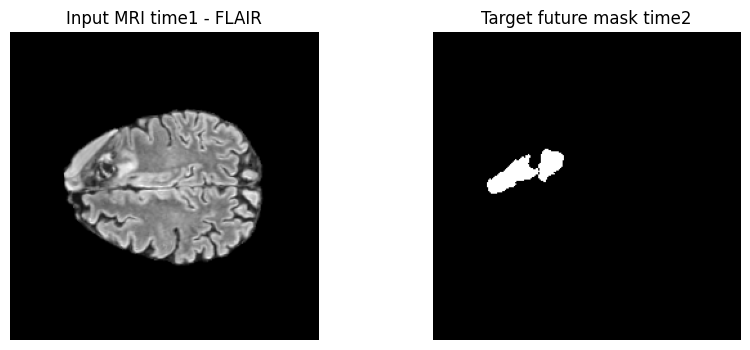

Input shape: torch.Size([4, 240, 240])
Mask shape: torch.Size([1, 240, 240])
Mask pixels: 908.0


In [23]:
x, y = train_dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(x[0], cmap="gray")
plt.title("Input MRI time1 - FLAIR")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y[0], cmap="gray")
plt.title("Target future mask time2")
plt.axis("off")

plt.show()

print("Input shape:", x.shape)
print("Mask shape:", y.shape)
print("Mask pixels:", y.sum().item())

## **Training**

In [24]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

***Metrics***

In [25]:
def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1 - dice.mean()


def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (
        preds.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return dice.mean().item()


def area_error(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    pred_area = preds.sum(dim=(1, 2, 3))
    true_area = targets.sum(dim=(1, 2, 3))

    return torch.abs(pred_area - true_area).mean().item()


bce_loss = nn.BCEWithLogitsLoss()

def total_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

**Run**

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = UNet2D(in_channels=4, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_area_error": []
}

best_dice = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = total_loss(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0
    val_area = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = total_loss(logits, y)

            val_loss += loss.item()
            val_dice += dice_score(logits, y)
            val_area += area_error(logits, y)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_area /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_area_error"].append(val_area)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val Dice={val_dice:.4f} | "
        f"Area Error={val_area:.2f}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_forecasting_unet.pth")
        print("Best model saved.")

Device: cuda


Epoch 1/20: 100%|██████████| 20/20 [04:27<00:00, 13.39s/it]


Epoch 1: Train Loss=1.4228 | Val Loss=1.5059 | Val Dice=0.2551 | Area Error=6462.70
Best model saved.


Epoch 2/20: 100%|██████████| 20/20 [01:22<00:00,  4.13s/it]


Epoch 2: Train Loss=1.3280 | Val Loss=1.3491 | Val Dice=0.3470 | Area Error=3842.90
Best model saved.


...

Epoch 18: Train Loss=1.0040 | Val Loss=1.0884 | Val Dice=0.5910 | Area Error=504.10
Best model saved.


Epoch 19/20: 100%|██████████| 20/20 [01:22<00:00,  4.13s/it]


Epoch 19: Train Loss=0.9943 | Val Loss=1.0687 | Val Dice=0.6171 | Area Error=825.40
Best model saved.


Epoch 20/20: 100%|██████████| 20/20 [01:22<00:00,  4.15s/it]


Epoch 20: Train Loss=0.9849 | Val Loss=1.0694 | Val Dice=0.5793 | Area Error=743.10


In [27]:
print("==== FINAL RESULTS ====")
print(f"Best Val Dice: {max(history['val_dice']):.4f}")
print(f"Final Val Dice: {history['val_dice'][-1]:.4f}")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Area Error: {history['val_area_error'][-1]:.2f}")

==== FINAL RESULTS ====
Best Val Dice: 0.6171
Final Val Dice: 0.5793
Final Val Loss: 1.0694
Final Area Error: 743.10


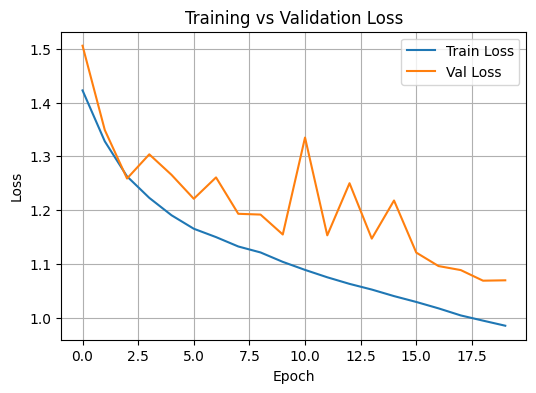

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

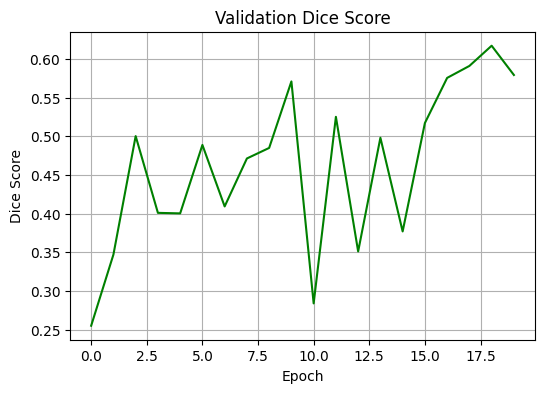

In [29]:
plt.figure(figsize=(6,4))
plt.plot(history["val_dice"], color="green")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice Score")
plt.grid()
plt.show()

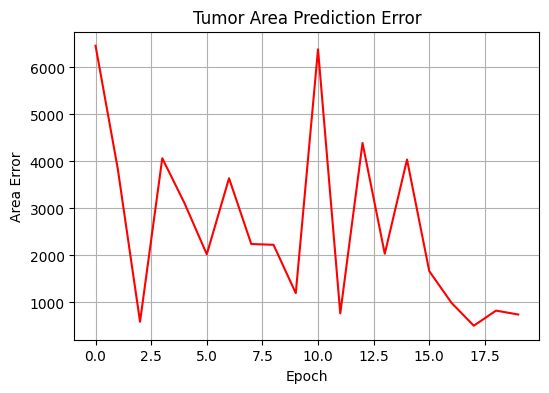

In [30]:
plt.figure(figsize=(6,4))
plt.plot(history["val_area_error"], color="red")
plt.xlabel("Epoch")
plt.ylabel("Area Error")
plt.title("Tumor Area Prediction Error")
plt.grid()
plt.show()

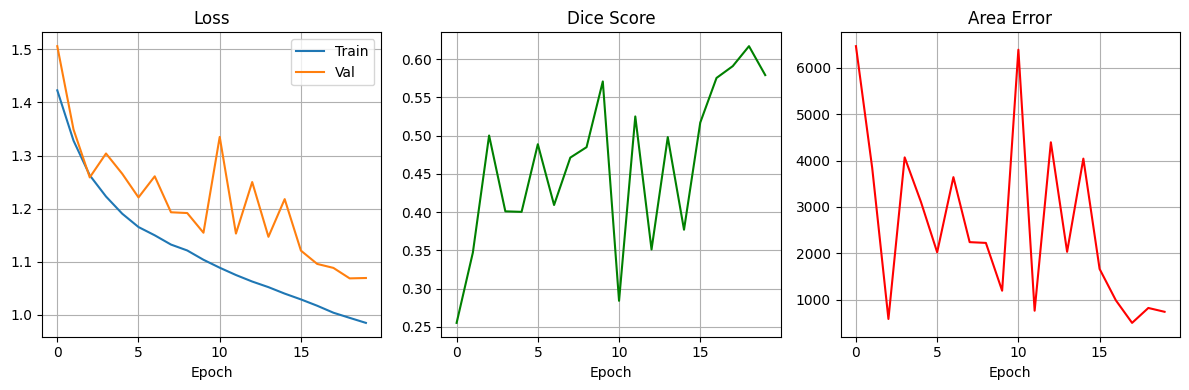

In [31]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,3,1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

# Dice
plt.subplot(1,3,2)
plt.plot(history["val_dice"], color="green")
plt.title("Dice Score")
plt.xlabel("Epoch")
plt.grid()

# Area error
plt.subplot(1,3,3)
plt.plot(history["val_area_error"], color="red")
plt.title("Area Error")
plt.xlabel("Epoch")
plt.grid()

plt.tight_layout()
plt.show()

In [32]:
plt.savefig("/content/drive/MyDrive/MEDICAL_IMAGE/Training/training_curves.png", dpi=300)

<Figure size 640x480 with 0 Axes>

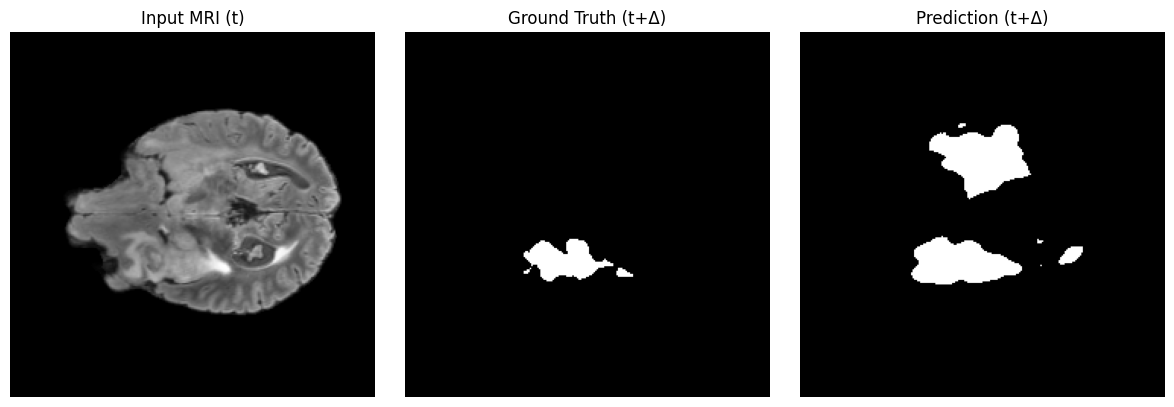

In [33]:
model.eval()

x, y = val_dataset[0]

with torch.no_grad():
    logits = model(x.unsqueeze(0).to(device))
    pred = torch.sigmoid(logits).cpu()[0, 0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(x[0], cmap="gray")
plt.title("Input MRI (t)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y[0], cmap="gray")
plt.title("Ground Truth (t+Δ)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Prediction (t+Δ)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
plt.savefig("/content/drive/MyDrive/MEDICAL_IMAGE/RESULTS/forecasting_result.png", dpi=300)

<Figure size 640x480 with 0 Axes>

## **Evaluation**

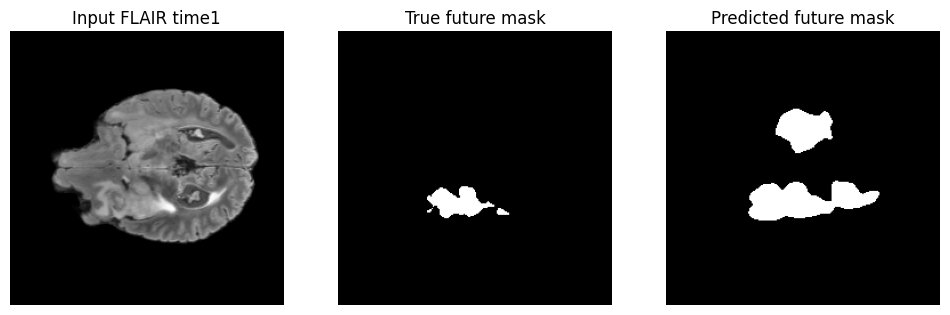

In [36]:
model.load_state_dict(torch.load("/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_forecasting_unet.pth"))
model.eval()

x, y = val_dataset[0]

with torch.no_grad():
    logits = model(x.unsqueeze(0).to(device))
    pred = torch.sigmoid(logits).cpu()[0, 0]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(x[0], cmap="gray")
plt.title("Input FLAIR time1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y[0], cmap="gray")
plt.title("True future mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted future mask")
plt.axis("off")

plt.show()

# **Multimodal U-Net**

### **Dataset**

In [39]:
import pandas as pd

CLINICAL_PATH = "/content/drive/MyDrive/MEDICAL_IMAGE/UCSF_PostopGlioma_Table_S1.xlsx"

clinical_df = pd.read_excel(CLINICAL_PATH, sheet_name="Clinical Info")
clinical_df.head()

,SubjectID,Days from 1st surgery/DX to 1st scan,Days from 1st scan to 2nd scan,EOR at 1st SX,WHO 2021 Diagnosis,Presumed Diagnosis,Grade,MGMT,MGMT methylation index,IDH,...,Days from death to 1st scan,Days from 1st scan to next progression,Days from 1st scan to 1st RT start (neg = RT first),1st Chemo type,Days from 1st chemo start to 1st scan,"On tx at 1st scan (c = chemo, rt, n = none)","On tx at 2nd scan (c = chemo, rt, n = none)",Number of surgeries,Days from 1st scan to 2nd SX,Days from 1st scan to 3rd SX
0,100001,8682.0,71.645139,GTR,Oligodendroglioma,Oligodendroglioma,NaN,NaN,NaN,mut,...,NaN,1095.0,33.0,NaN,NaN,n,rt,2,4090.0,NaN
1,100002,3870.0,182.568750,MRI,Oligodendroglioma,Oligodendroglioma,2.0,positive,17.0,mut,...,NaN,1218.0,NaN,NaN,NaN,n,n,3,775.0,-1218.0
2,100003,734.0,138.715278,NaN,Oligodendroglioma,Oligodendroglioma,3.0,positive,NaN,mut,...,NaN,NaN,-702.0,TMZ,642.0,n,n,1,NaN,NaN
3,100004,233.0,56.567361,GTR,Glioblastoma,Glioblastoma,4.0,positive,7.0,WT,...,-505.0,216.0,-204.0,TMZ,160.0,n,n,1,NaN,NaN
4,100005,177.0,65.441667,GTR,IDH mut Astrocytoma,Grade 2/3 IDH Mutant Astrocytoma,3.0,NaN,NaN,mut,...,NaN,NaN,-139.0,TMZ,139.0,n,n,1,NaN,NaN


In [40]:
clinical_cols = [
    "SubjectID",
    "Days from 1st scan to 2nd scan",
    "EOR at 1st SX",
    "Grade",
    "MGMT",
    "IDH",
    "1p19q",
    "ATRX",
    "On tx at 1st scan (c = chemo, rt, n = none)",
    "On tx at 2nd scan (c = chemo, rt, n = none)",
    "Number of surgeries"
]

clinical_df = clinical_df[clinical_cols].copy()
clinical_df["SubjectID"] = clinical_df["SubjectID"].astype(str)
clinical_df.head()

,SubjectID,Days from 1st scan to 2nd scan,EOR at 1st SX,Grade,MGMT,IDH,1p19q,ATRX,"On tx at 1st scan (c = chemo, rt, n = none)","On tx at 2nd scan (c = chemo, rt, n = none)",Number of surgeries
0,100001,71.645139,GTR,NaN,NaN,mut,codel,intact,n,rt,2
1,100002,182.568750,MRI,2.0,positive,mut,codel,intact,n,n,3
2,100003,138.715278,NaN,3.0,positive,mut,codel,NaN,n,n,1
3,100004,56.567361,GTR,4.0,positive,WT,intact,NaN,n,n,1
4,100005,65.441667,GTR,3.0,NaN,mut,NaN,loss,n,n,1


**Vector**

In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

numeric_cols = [
    "Days from 1st scan to 2nd scan",
    "Grade",
    "Number of surgeries"
]

categorical_cols = [
    "EOR at 1st SX",
    "MGMT",
    "IDH",
    "1p19q",
    "ATRX",
    "On tx at 1st scan (c = chemo, rt, n = none)",
    "On tx at 2nd scan (c = chemo, rt, n = none)"
]

clinical_df[numeric_cols] = clinical_df[numeric_cols].fillna(0)
clinical_df[categorical_cols] = clinical_df[categorical_cols].fillna("unknown").astype(str)

scaler = StandardScaler()
num_features = scaler.fit_transform(clinical_df[numeric_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_features = encoder.fit_transform(clinical_df[categorical_cols])

clinical_features = np.concatenate([num_features, cat_features], axis=1)

clinical_dict = {
    str(pid): clinical_features[i].astype(np.float32)
    for i, pid in enumerate(clinical_df["SubjectID"])
}

clinical_dim = clinical_features.shape[1]

print("Clinical feature dimension:", clinical_dim)
print("Example patient:", list(clinical_dict.keys())[0])
print(clinical_dict[list(clinical_dict.keys())[0]].shape)

Clinical feature dimension: 28
Example patient: 100001
(28,)


In [42]:
def build_samples_with_clinical(data_dir, clinical_dict):
    samples = []

    patients = sorted(os.listdir(data_dir))

    for p in patients:
        folder = os.path.join(data_dir, p)

        if not os.path.isdir(folder):
            continue

        if p not in clinical_dict:
            print("No clinical data for:", p)
            continue

        sample = {
            "patient_id": p,
            "flair_t1": os.path.join(folder, f"{p}_time1_flair.nii.gz"),
            "t1_t1": os.path.join(folder, f"{p}_time1_t1.nii.gz"),
            "t1ce_t1": os.path.join(folder, f"{p}_time1_t1ce.nii.gz"),
            "t2_t1": os.path.join(folder, f"{p}_time1_t2.nii.gz"),
            "mask_t2": os.path.join(folder, f"{p}_time2_seg.nii.gz"),
            "clinical": clinical_dict[p]
        }

        if all(os.path.exists(v) for k, v in sample.items() if k not in ["patient_id", "clinical"]):
            samples.append(sample)

    return samples


samples = build_samples_with_clinical(DATA_DIR, clinical_dict)

print("Total samples with clinical data:", len(samples))
print(samples[0]["clinical"].shape)

No clinical data for: RESULTS
No clinical data for: Training
Total samples with clinical data: 50
(28,)


In [43]:
class TumorForecastClinicalDataset(Dataset):
    def __init__(self, samples, size=240):
        self.samples = samples
        self.size = size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        flair = normalize_volume(load_nifti(s["flair_t1"]))
        t1 = normalize_volume(load_nifti(s["t1_t1"]))
        t1ce = normalize_volume(load_nifti(s["t1ce_t1"]))
        t2 = normalize_volume(load_nifti(s["t2_t1"]))
        mask = load_nifti(s["mask_t2"])

        mask_binary = (mask > 0).astype(np.float32)

        slice_scores = mask_binary.sum(axis=(0, 1))

        if slice_scores.max() > 0:
            z = int(np.argmax(slice_scores))
        else:
            z = mask_binary.shape[2] // 2

        x_img = np.stack([
            flair[:, :, z],
            t1[:, :, z],
            t1ce[:, :, z],
            t2[:, :, z]
        ], axis=0)

        y = mask_binary[:, :, z][None, :, :]

        x_img = torch.tensor(x_img, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        x_img = F.interpolate(
            x_img.unsqueeze(0),
            size=(self.size, self.size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        y = F.interpolate(
            y.unsqueeze(0),
            size=(self.size, self.size),
            mode="nearest"
        ).squeeze(0)

        x_clinical = torch.tensor(s["clinical"], dtype=torch.float32)

        return x_img, x_clinical, y

## **Model**

In [44]:
class ClinicalEncoder(nn.Module):
    def __init__(self, clinical_dim, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(clinical_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, embed_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class MultimodalUNetForecast(nn.Module):
    def __init__(self, in_channels=4, clinical_dim=10, clinical_embed_dim=64):
        super().__init__()

        self.clinical_encoder = ClinicalEncoder(clinical_dim, clinical_embed_dim)

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128 + clinical_embed_dim, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x_img, x_clinical):
        e1 = self.enc1(x_img)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.pool3(e3)

        c = self.clinical_encoder(x_clinical)
        c = c[:, :, None, None]
        c = c.expand(-1, -1, b.shape[2], b.shape[3])

        b = torch.cat([b, c], dim=1)
        b = self.bottleneck(b)

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

## **Loaders**

In [45]:
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    random_state=42
)

train_dataset = TumorForecastClinicalDataset(train_samples)
val_dataset = TumorForecastClinicalDataset(val_samples)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)

## **Trainig**

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalUNetForecast(
    in_channels=4,
    clinical_dim=clinical_dim,
    clinical_embed_dim=64
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 20

history_mm = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_area_error": []
}

best_dice = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x_img, x_clinical, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x_img = x_img.to(device)
        x_clinical = x_clinical.to(device)
        y = y.to(device)

        logits = model(x_img, x_clinical)
        loss = total_loss(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    val_dice = 0
    val_area = 0

    with torch.no_grad():
        for x_img, x_clinical, y in val_loader:
            x_img = x_img.to(device)
            x_clinical = x_clinical.to(device)
            y = y.to(device)

            logits = model(x_img, x_clinical)
            loss = total_loss(logits, y)

            val_loss += loss.item()
            val_dice += dice_score(logits, y)
            val_area += area_error(logits, y)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_area /= len(val_loader)

    history_mm["train_loss"].append(train_loss)
    history_mm["val_loss"].append(val_loss)
    history_mm["val_dice"].append(val_dice)
    history_mm["val_area_error"].append(val_area)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val Dice={val_dice:.4f} | "
        f"Area Error={val_area:.2f}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_multimodal_forecasting_unet.pth"
        )
        print("Best multimodal model saved.")

Epoch 1/20: 100%|██████████| 20/20 [01:35<00:00,  4.78s/it]


Epoch 1: Train Loss=1.5975 | Val Loss=1.5957 | Val Dice=0.2353 | Area Error=7869.90
Best multimodal model saved.


Epoch 2/20: 100%|██████████| 20/20 [01:23<00:00,  4.18s/it]


Epoch 2: Train Loss=1.4677 | Val Loss=1.7146 | Val Dice=0.2834 | Area Error=7222.20
Best multimodal model saved.


Epoch 3/20: 100%|██████████| 20/20 [01:26<00:00,  4.31s/it]


...

Epoch 18: Train Loss=1.1411 | Val Loss=1.2083 | Val Dice=0.6240 | Area Error=738.70


Epoch 19/20: 100%|██████████| 20/20 [01:23<00:00,  4.19s/it]


Epoch 19: Train Loss=1.1293 | Val Loss=1.2270 | Val Dice=0.5193 | Area Error=1385.50


Epoch 20/20: 100%|██████████| 20/20 [01:20<00:00,  4.05s/it]


Epoch 20: Train Loss=1.1171 | Val Loss=1.1849 | Val Dice=0.6490 | Area Error=630.40


In [48]:
print("==== MULTIMODAL RESULTS ====")
print(f"Best Val Dice: {max(history_mm['val_dice']):.4f}")
print(f"Final Val Dice: {history_mm['val_dice'][-1]:.4f}")
print(f"Final Val Loss: {history_mm['val_loss'][-1]:.4f}")
print(f"Final Area Error: {history_mm['val_area_error'][-1]:.2f}")

==== MULTIMODAL RESULTS ====
Best Val Dice: 0.6697
Final Val Dice: 0.6490
Final Val Loss: 1.1849
Final Area Error: 630.40


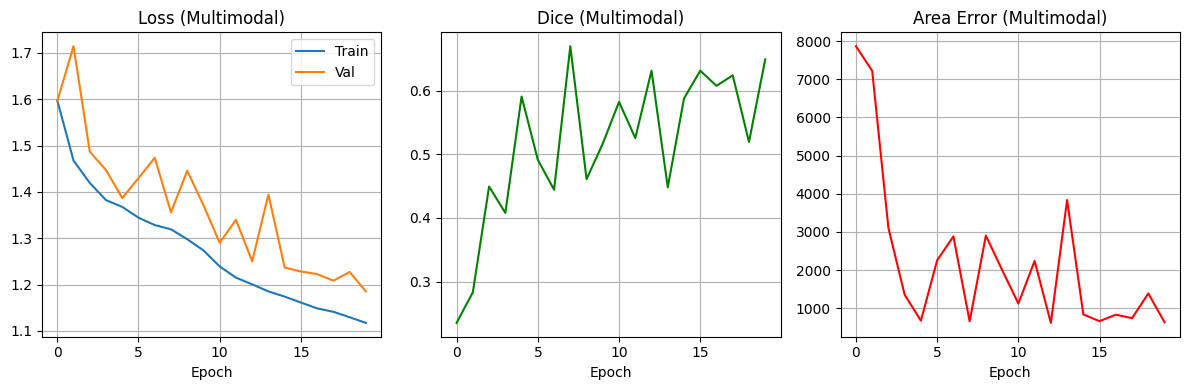

In [49]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,3,1)
plt.plot(history_mm["train_loss"], label="Train")
plt.plot(history_mm["val_loss"], label="Val")
plt.title("Loss (Multimodal)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

# Dice
plt.subplot(1,3,2)
plt.plot(history_mm["val_dice"], color="green")
plt.title("Dice (Multimodal)")
plt.xlabel("Epoch")
plt.grid()

# Area error
plt.subplot(1,3,3)
plt.plot(history_mm["val_area_error"], color="red")
plt.title("Area Error (Multimodal)")
plt.xlabel("Epoch")
plt.grid()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MEDICAL_IMAGE/Training/multimodal_training_curves.png", dpi=300)
plt.show()

## **Evaluation**

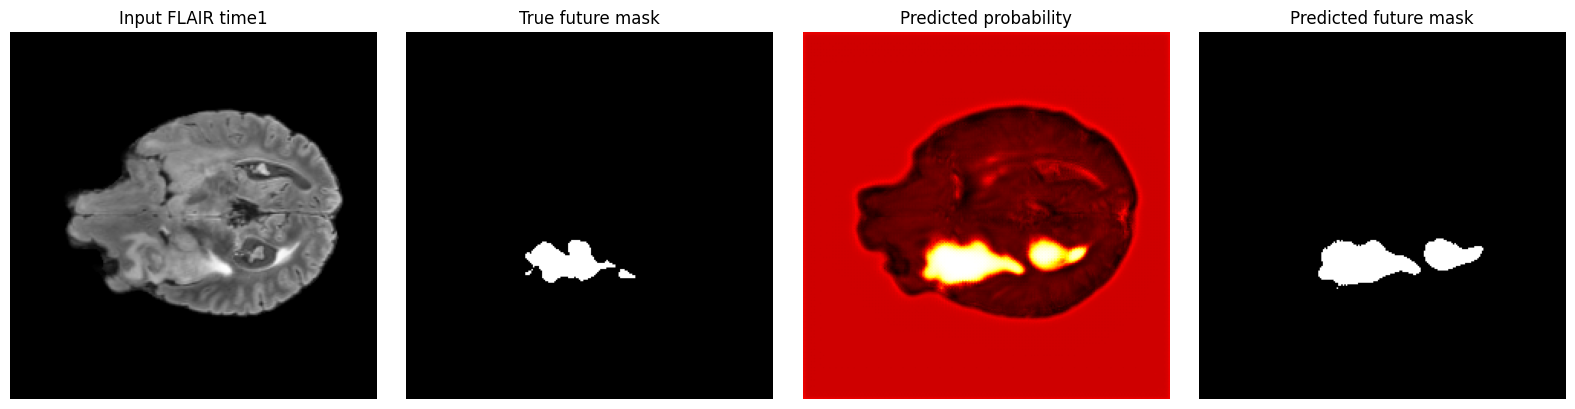

In [50]:
# =========================
# Multimodal model evaluation visualization
# =========================

multimodal_model = MultimodalUNetForecast(
    in_channels=4,
    clinical_dim=clinical_dim,
    clinical_embed_dim=64
).to(device)

multimodal_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_multimodal_forecasting_unet.pth",
        map_location=device
    )
)

multimodal_model.eval()

# Tomar un ejemplo del validation set
x_img, x_clinical, y = val_dataset[0]

with torch.no_grad():
    logits = multimodal_model(
        x_img.unsqueeze(0).to(device),
        x_clinical.unsqueeze(0).to(device)
    )

    pred_prob = torch.sigmoid(logits).cpu()[0, 0]
    pred_mask = pred_prob > 0.5

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_img[0], cmap="gray")
plt.title("Input FLAIR time1")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(y[0], cmap="gray")
plt.title("True future mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_prob, cmap="hot")
plt.title("Predicted probability")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted future mask")
plt.axis("off")

plt.tight_layout()
plt.show()

# **Comparision**

In [51]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

# =========================
# 1. Re-create SAME datasets
# =========================

train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    random_state=42
)

val_dataset_img = TumorForecastDataset(val_samples)
val_dataset_mm = TumorForecastClinicalDataset(val_samples)

val_loader_img = DataLoader(val_dataset_img, batch_size=2, shuffle=False, num_workers=0)
val_loader_mm = DataLoader(val_dataset_mm, batch_size=2, shuffle=False, num_workers=0)


# =========================
# 2. Load image-only model
# =========================

image_model = UNet2D(in_channels=4, out_channels=1).to(device)
image_model.load_state_dict(
    torch.load("/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_forecasting_unet.pth",
               map_location=device)
)
image_model.eval()


# =========================
# 3. Load multimodal model
# =========================

multimodal_model = MultimodalUNetForecast(
    in_channels=4,
    clinical_dim=clinical_dim,
    clinical_embed_dim=64
).to(device)

multimodal_model.load_state_dict(
    torch.load("/content/drive/MyDrive/MEDICAL_IMAGE/Training/best_multimodal_forecasting_unet.pth",
               map_location=device)
)
multimodal_model.eval()


# =========================
# 4. Evaluation functions
# =========================

def evaluate_image_only(model, loader):
    total_loss_value = 0
    total_dice = 0
    total_area = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = total_loss(logits, y)

            total_loss_value += loss.item()
            total_dice += dice_score(logits, y)
            total_area += area_error(logits, y)

    n = len(loader)

    return {
        "Loss": total_loss_value / n,
        "Dice Score": total_dice / n,
        "Area Error": total_area / n
    }


def evaluate_multimodal(model, loader):
    total_loss_value = 0
    total_dice = 0
    total_area = 0

    with torch.no_grad():
        for x_img, x_clinical, y in loader:
            x_img = x_img.to(device)
            x_clinical = x_clinical.to(device)
            y = y.to(device)

            logits = model(x_img, x_clinical)
            loss = total_loss(logits, y)

            total_loss_value += loss.item()
            total_dice += dice_score(logits, y)
            total_area += area_error(logits, y)

    n = len(loader)

    return {
        "Loss": total_loss_value / n,
        "Dice Score": total_dice / n,
        "Area Error": total_area / n
    }


# =========================
# 5. Run evaluation
# =========================

results_img = evaluate_image_only(image_model, val_loader_img)
results_mm = evaluate_multimodal(multimodal_model, val_loader_mm)

comparison_df = pd.DataFrame({
    "Image-only U-Net": results_img,
    "Multimodal U-Net": results_mm
}).T

comparison_df

,Loss,Dice Score,Area Error
Image-only U-Net,1.068674,0.617150,825.4
Multimodal U-Net,1.355767,0.669734,654.5


In [52]:
print("===== MODEL COMPARISON =====")
print(comparison_df.round(4))

===== MODEL COMPARISON =====
                    Loss  Dice Score  Area Error
Image-only U-Net  1.0687      0.6171       825.4
Multimodal U-Net  1.3558      0.6697       654.5


In [53]:
comparison_df.to_csv("/content/drive/MyDrive/MEDICAL_IMAGE/RESULTS/model_comparison_results.csv")

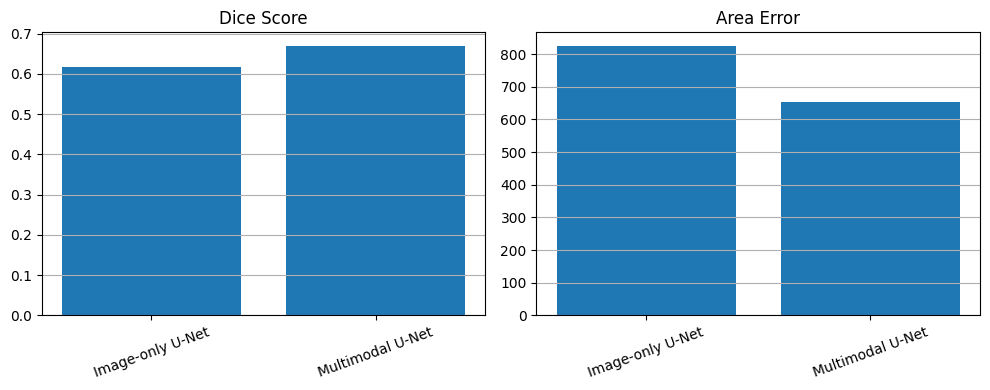

In [54]:
plt.figure(figsize=(10,4))

metrics = ["Dice Score", "Area Error"]

for i, metric in enumerate(metrics):
    plt.subplot(1, 2, i+1)
    plt.bar(comparison_df.index, comparison_df[metric])
    plt.title(metric)
    plt.xticks(rotation=20)
    plt.grid(axis="y")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MEDICAL_IMAGE/RESULTS/model_comparison_plot.png", dpi=300)
plt.show()

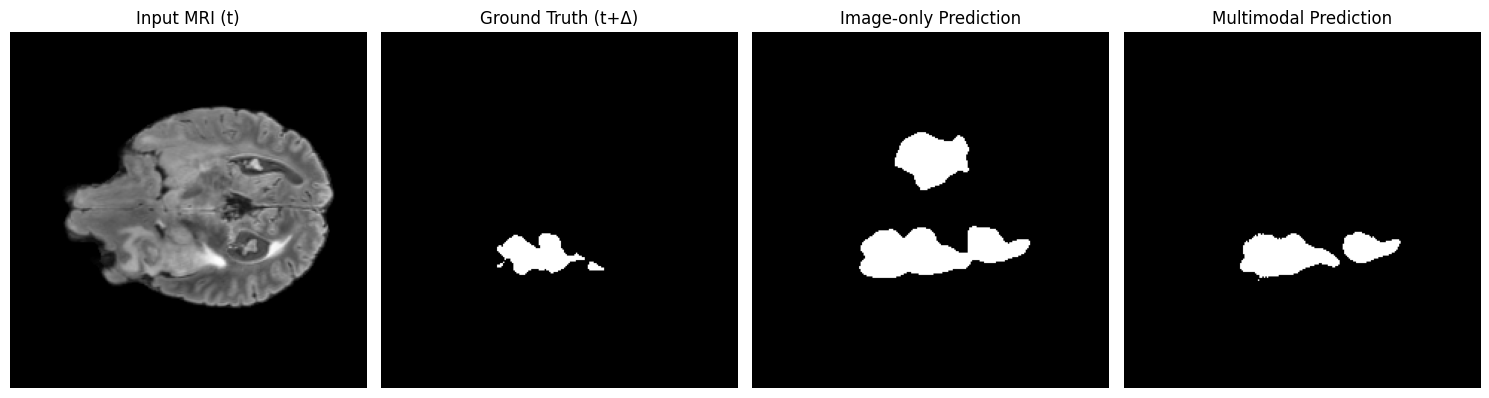

In [57]:
# =========================
# Comparación visual directa
# =========================

image_model.eval()
multimodal_model.eval()

# escoger un ejemplo del validation set
idx = 0
x_img, x_clinical, y = val_dataset_mm[idx]

with torch.no_grad():
    # Image-only
    logits_img = image_model(x_img.unsqueeze(0).to(device))
    pred_img = torch.sigmoid(logits_img).cpu()[0, 0]

    # Multimodal
    logits_mm = multimodal_model(
        x_img.unsqueeze(0).to(device),
        x_clinical.unsqueeze(0).to(device)
    )
    pred_mm = torch.sigmoid(logits_mm).cpu()[0, 0]

# convertir a máscaras binarias
pred_img_bin = (pred_img > 0.5)
pred_mm_bin = (pred_mm > 0.5)

# =========================
# Visualización
# =========================

plt.figure(figsize=(15,4))

# Input
plt.subplot(1,4,1)
plt.imshow(x_img[0], cmap="gray")
plt.title("Input MRI (t)")
plt.axis("off")

# Ground truth
plt.subplot(1,4,2)
plt.imshow(y[0], cmap="gray")
plt.title("Ground Truth (t+Δ)")
plt.axis("off")

# Image-only
plt.subplot(1,4,3)
plt.imshow(pred_img_bin, cmap="gray")
plt.title("Image-only Prediction")
plt.axis("off")

# Multimodal
plt.subplot(1,4,4)
plt.imshow(pred_mm_bin, cmap="gray")
plt.title("Multimodal Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

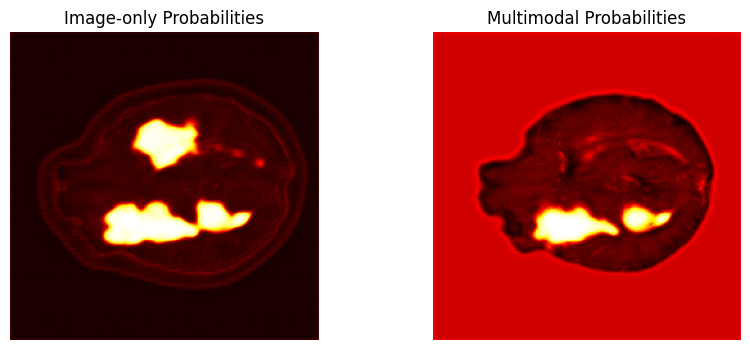

In [58]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(pred_img, cmap="hot")
plt.title("Image-only Probabilities")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_mm, cmap="hot")
plt.title("Multimodal Probabilities")
plt.axis("off")

plt.show()